In [1]:
# Package imports
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def lineStartsWith(line, strings):
    for string in strings:
        lenStr = len(string)
        if line[0:lenStr] == string:
            return True
    return False

In [18]:
def createGraphs(xVec, yVecs, legendLabels, title, xLabel, yLabel, yticks=None, fileName=None):
    """
    xVec        : List containing the x-values for our plot
    yVecs       : List of Lists that contain the different items we want to plot
    legendLabels: List of labels for the graph. Must be the same length as yVecs.
    title       : Title of the plot
    xLabel      : Label for the x-axis
    yLabel      : Label for the y-axis
    fileName    : Name of the file we want to save to. If None, then we do not 
        save to a file and instead just display.
    """
    fig,ax = plt.subplots()
    ax.set_title(title)
    ax.set_xlabel(xLabel)
    ax.set_ylabel(yLabel)
    if(len(yVecs) != len(legendLabels)):
        print("yVecs and legendLabels do not have the same length")
        return
    numYVecs = len(yVecs)
    for i in range(numYVecs):
        ax.plot(xVec, yVecs[i], label=legendLabels[i])
    ax.legend()
    fig.show()
    if (yticks != None):
        plt.yticks(yticks)
    if (fileName != None):
        fig.savefig(fileName)

In [18]:
def readDgeqrfFile(fileName):
    """
        This function reads the file given by fileName and returns an array of arrays of the 
        reference and recursive values along with the m and nb vals for each.
        Since our data is for two different experiments, there is a -Inf seperating each ie
        avgRec{Time,Perf} = [val1, val2, ..., valn, -Inf, val1, val2, ..., valn]
        [avgRefTime, avgRefPerf, avgRecTime, avgRecPerf, avgQr3Time, avgQr3Perf, m, n, nb]

        Note: The time arrays are mostly used as a sanity check. If we see a stagnating or 
        decreasing time graph we have a problem with the experiments and then means that I
        trust the performance graphs to be correct.
    """
    avgRefTime = np.zeros(0)
    avgRefPerf = np.zeros(0)
    avgRecTime = np.zeros(0)
    avgRecPerf = np.zeros(0)
    avgQr3Time = np.zeros(0)
    avgQr3Perf = np.zeros(0)
    mVec = np.zeros(0).astype("int")
    nVec = np.zeros(0).astype("int")
    nbVec = np.zeros(0).astype("int")
    invalidFileMessage = "Invalid file!\n" + "Please ensure you use the one my shell script outputs"
    
    avgRefTimeTmp = 0
    avgRefPerfTmp = 0
    avgRecTimeTmp = 0
    avgRecPerfTmp = 0
    avgQr3TimeTmp = 0
    avgQr3PerfTmp = 0
    firstRun = True
    # Number of times we repeat each test. Currently I always do 10. This can be
    # changed and parsed along with this file if we want to capture some more 
    # information about the distrubution of values, but that's beyond the scope 
    # of what we are currently looking at.
    numRepeat = 10
    # Open the file and immediately close once done
    with open(fileName, 'r') as file:
        # Read the file line by line
        for line in file:
            # Parse the line.
            # If the line starts with "T" or "C" then we skip it. This is for debugging and
            #  visual inspection
            if lineStartsWith(line, ["T", "C", "W"]):
                if lineStartsWith(line, ["Test", "Try", "Wide"]):
                    if not firstRun:
                        avgRefTime = np.append(avgRefTime, avgRefTimeTmp/numRepeat)
                        avgRefPerf = np.append(avgRefPerf, avgRefPerfTmp/numRepeat)
                        avgRecTime = np.append(avgRecTime, avgRecTimeTmp/numRepeat)
                        avgRecPerf = np.append(avgRecPerf, avgRecPerfTmp/numRepeat)
                        avgQr3Time = np.append(avgQr3Time, avgQr3TimeTmp/numRepeat)
                        avgQr3Perf = np.append(avgQr3Perf, avgQr3PerfTmp/numRepeat)
                    if lineStartsWith(line, ["Try", "Wide"]): 
                        # Input our seperator 
                        avgRefTime = np.append(avgRefTime, -np.inf)
                        avgRefPerf = np.append(avgRefPerf, -np.inf)
                        avgRecTime = np.append(avgRecTime, -np.inf)
                        avgRecPerf = np.append(avgRecPerf, -np.inf)
                        avgQr3Time = np.append(avgQr3Time, -np.inf)
                        avgQr3Perf = np.append(avgQr3Perf, -np.inf)
                        mVec  = np.append(mVec,  -np.inf)
                        nVec  = np.append(nVec,  -np.inf)
                        nbVec = np.append(nbVec, -np.inf)
                        # Make sure that we don't accidentally add a 0 to our arrays
                        firstRun = True
                    avgRefTimeTmp = 0
                    avgRefPerfTmp = 0
                    avgRecTimeTmp = 0
                    avgRecPerfTmp = 0
                    avgQr3TimeTmp = 0
                    avgQr3PerfTmp = 0
                    if not lineStartsWith(line, ["Try", "Wide"]):
                        firstRun = False
                continue
            # If the line starts with "m" then we parse it iff it contains nb. This
            #  is used to print out the parameters used. This is needed for us
            if line[0] == 'm':
                # Determine if we are on a line that contains nb
                tokens = line.split(" ")
                if tokens[-1][0:2] == "nb":
                    # This means we need to update our size info. Since the parameter of 
                    # interest varies from test to test, we print out all sizes and 
                    # grab them all then determine which we want to print out
                    # later. There may be a smarter way to do this.
                    try:
                        m = int(tokens[0][2:])
                        n = int(tokens[1][2:])
                        nb= int(tokens[2][3:])
                    except:
                        print(invalidFileMessage)
                        return None
                    mVec  = np.append(mVec,  m)
                    nVec  = np.append(nVec,  n)
                    nbVec = np.append(nbVec, nb)
                else:
                    # Then we have a line that's only for visual inspection, so skip it
                    continue
            else:
                # Grab the part of the line that is after our marker
                break1 = line.split(":")
                try:
                    valPortion = break1[1]
                except:
                    print(break1)
                    print(line)
                    return None
                vals = valPortion.split("|")
                try:
                    timeVal = float(vals[0])
                    perfVal = float(vals[1])
                    #print(timeVal)
                    #print(perfVal)
                except:
                    print(invalidFileMessage)
                    return None
                # Then we need to determine if we have a recursive or reference line 
                typeString = break1[0]
                #print(typeString)
                if typeString == "rec":
                    # This means we have a line that gives us the recursive results.
                    avgRecTimeTmp += timeVal
                    avgRecPerfTmp += perfVal
                elif typeString == "ref":
                    # This means we have a line that gives us the reference results.
                    avgRefTimeTmp += timeVal
                    avgRefPerfTmp += perfVal
                elif typeString == "qr3":
                    # This means we have a line that gives the results for when we are using
                    #  dgeqrt3 instead of dgeqr2 + dlarft
                    avgQr3TimeTmp += timeVal
                    avgQr3PerfTmp += perfVal
                else:
                    # This file is not properly formatted, inform the user and bail out
                    print(invalidFileMessage)
                    return None
    # Get ready to return our data
    avgRefTime = np.append(avgRefTime, avgRefTimeTmp/numRepeat)
    avgRefPerf = np.append(avgRefPerf, avgRefPerfTmp/numRepeat)
    avgRecTime = np.append(avgRecTime, avgRecTimeTmp/numRepeat)
    avgRecPerf = np.append(avgRecPerf, avgRecPerfTmp/numRepeat)
    avgQr3Time = np.append(avgQr3Time, avgQr3TimeTmp/numRepeat)
    avgQr3Perf = np.append(avgQr3Perf, avgQr3PerfTmp/numRepeat)
    return [avgRefTime, avgRefPerf, avgRecTime, avgRecPerf, avgQr3Time, avgQr3Perf, mVec, nVec, nbVec]

In [19]:
[avgRefTime, avgRefPerf, avgRecTime, avgRecPerf, avgQr3Time, avgQr3Perf, m, n, nb] = readDgeqrfFile("./larft/realDouble/cTesters/dgeqrf_timing.24.November.2024.txt")

In [20]:
print(avgRefTime)
print(nb)

[5.978290e+00 7.735050e+00 9.231000e+00 1.085502e+01 1.238130e+01
 1.337100e+01 1.613360e+01 1.700940e+01 1.778360e+01 1.932280e+01
 2.181070e+01 2.399350e+01 2.738670e+01 2.618180e+01 2.834180e+01
 3.489670e+01 3.896850e+01 4.015840e+01 4.173990e+01 4.135340e+01
 4.368510e+01 4.593800e+01 4.204610e+01 4.361900e+01 4.542960e+01
 5.068920e+01 5.334360e+01 6.047110e+01 6.148940e+01 6.190920e+01
 6.530420e+01 6.540840e+01 6.416510e+01 6.390720e+01 6.755010e+01
 7.195240e+01 7.821330e+01 8.316010e+01 8.486770e+01 7.777920e+01
 7.786700e+01 8.244530e+01 8.737090e+01 8.882020e+01 9.189100e+01
         -inf 1.367900e-03 1.620750e-02 3.627160e-02 6.085680e-02
 9.251450e-02 1.320750e-01 1.727370e-01 2.218590e-01 2.810020e-01
 3.476010e-01 4.246140e-01 4.912550e-01 5.760800e-01 6.687370e-01
 7.638780e-01 8.635120e-01 9.791750e-01 1.089230e+00 1.210080e+00
 1.322630e+00         -inf 8.371540e+01 5.371010e+01 4.545540e+01
 4.347460e+01 3.531710e+01 3.813210e+01 4.625320e+01 6.255430e+01
 8.679360e

In [21]:
index1Stop = -1
index2Start = -1
index2Stop = -1
index3Start = -1
for i in range(len(avgRefTime)):
    if avgRefTime[i] == -np.inf:
        if index1Stop == -1:
            index1Stop = i
            index2Start = i+1
        elif index2Stop == -1:
            index2Stop = i
            index3Start = i+1
            break
print(avgRefTime[0:index1Stop])
print(avgRefTime[index2Start:index2Stop])
print(avgRefTime[index3Start:])
print(nb[index3Start:])
print(m[0:index1Stop])

[ 5.97829  7.73505  9.231   10.85502 12.3813  13.371   16.1336  17.0094
 17.7836  19.3228  21.8107  23.9935  27.3867  26.1818  28.3418  34.8967
 38.9685  40.1584  41.7399  41.3534  43.6851  45.938   42.0461  43.619
 45.4296  50.6892  53.3436  60.4711  61.4894  61.9092  65.3042  65.4084
 64.1651  63.9072  67.5501  71.9524  78.2133  83.1601  84.8677  77.7792
 77.867   82.4453  87.3709  88.8202  91.891  ]
[0.0013679 0.0162075 0.0362716 0.0608568 0.0925145 0.132075  0.172737
 0.221859  0.281002  0.347601  0.424614  0.491255  0.57608   0.668737
 0.763878  0.863512  0.979175  1.08923   1.21008   1.32263  ]
[ 83.7154  53.7101  45.4554  43.4746  35.3171  38.1321  46.2532  62.5543
  86.7936 139.008 ]
[  16.   32.   64.  128.  256.  512. 1024. 2048. 4096. 8192.]
[ 5000.  6000.  7000.  8000.  9000. 10000. 11000. 12000. 13000. 14000.
 15000. 16000. 17000. 18000. 19000. 20000. 21000. 22000. 23000. 24000.
 25000. 26000. 27000. 28000. 29000. 30000. 31000. 32000. 33000. 34000.
 35000. 36000. 37000. 38

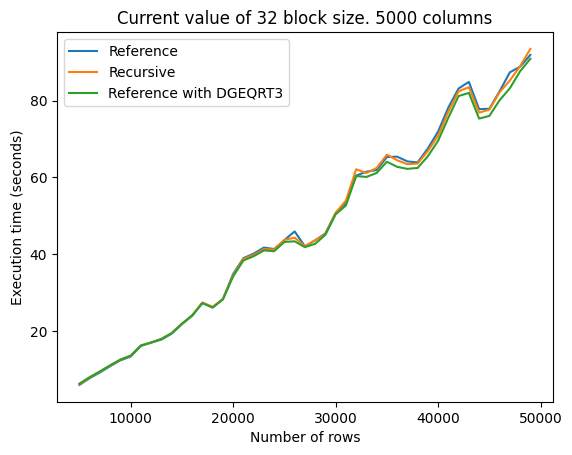

In [22]:
plt.plot(m[0:index1Stop],avgRefTime[0:index1Stop],label="Reference")
plt.plot(m[0:index1Stop],avgRecTime[0:index1Stop],label="Recursive")
plt.plot(m[0:index1Stop],avgQr3Time[0:index1Stop],label="Reference with DGEQRT3")
plt.legend()
plt.title("Current value of 32 block size. 5000 columns")
plt.xlabel("Number of rows")
plt.ylabel("Execution time (seconds)")
plt.savefig("currentBlocksizeTime.pdf")

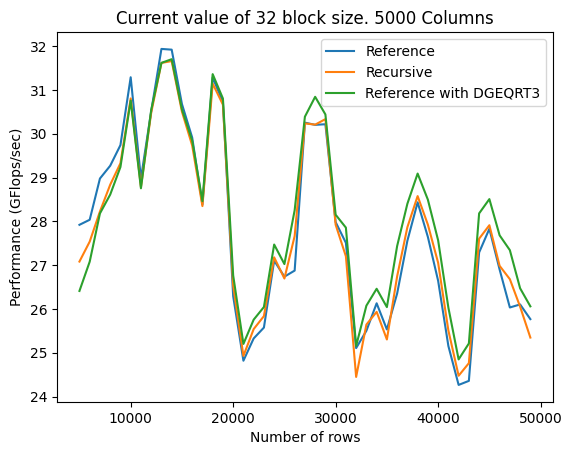

In [7]:
plt.plot(m[0:index1Stop],avgRefPerf[0:index1Stop],label="Reference")
plt.plot(m[0:index1Stop],avgRecPerf[0:index1Stop],label="Recursive")
plt.plot(m[0:index1Stop],avgQr3Perf[0:index1Stop],label="Reference with DGEQRT3")
plt.legend()
plt.title("Current value of 32 block size. 5000 Columns")
plt.xlabel("Number of rows")
plt.ylabel("Performance (GFlops/sec)")
plt.savefig("currentBlocksizePerf.pdf")

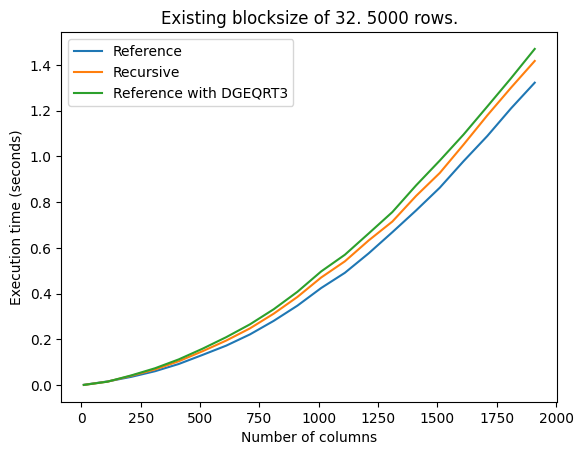

In [8]:
plt.plot(n[index2Start:index2Stop],avgRefTime[index2Start:index2Stop],label="Reference")
plt.plot(n[index2Start:index2Stop],avgRecTime[index2Start:index2Stop],label="Recursive")
plt.plot(n[index2Start:index2Stop],avgQr3Time[index2Start:index2Stop],label="Reference with DGEQRT3")
plt.legend()
plt.title("Existing blocksize of 32. 5000 rows.")
plt.xlabel("Number of columns")
plt.ylabel("Execution time (seconds)")
plt.savefig("existingBlocksizeWideTime.pdf")

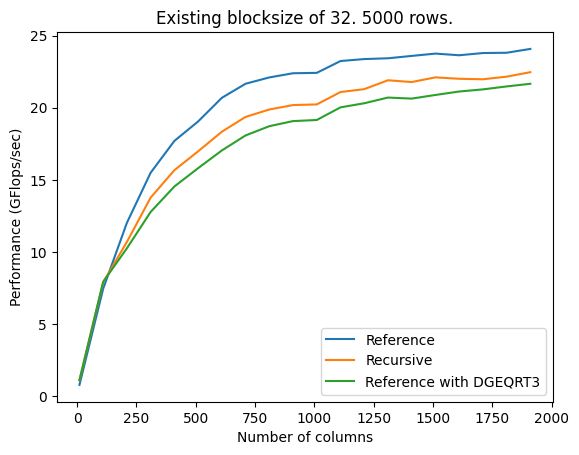

In [9]:
plt.plot(n[index2Start:index2Stop],avgRefPerf[index2Start:index2Stop],label="Reference")
plt.plot(n[index2Start:index2Stop],avgRecPerf[index2Start:index2Stop],label="Recursive")
plt.plot(n[index2Start:index2Stop],avgQr3Perf[index2Start:index2Stop],label="Reference with DGEQRT3")
plt.legend()
plt.title("Existing blocksize of 32. 5000 rows.")
plt.xlabel("Number of columns")
plt.ylabel("Performance (GFlops/sec)")
plt.savefig("existingBlocksizeWidePerf.pdf")

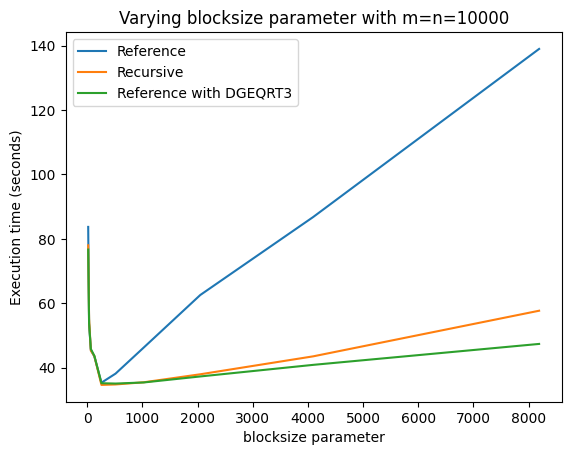

In [10]:
plt.plot(nb[index3Start:],avgRefTime[index3Start:],label="Reference")
plt.plot(nb[index3Start:],avgRecTime[index3Start:],label="Recursive")
plt.plot(nb[index3Start:],avgQr3Time[index3Start:],label="Reference with DGEQRT3")
plt.legend()
plt.title("Varying blocksize parameter with m=n=10000")
plt.xlabel("blocksize parameter")
plt.ylabel("Execution time (seconds)")
plt.savefig("newBlocksizeTime.pdf")

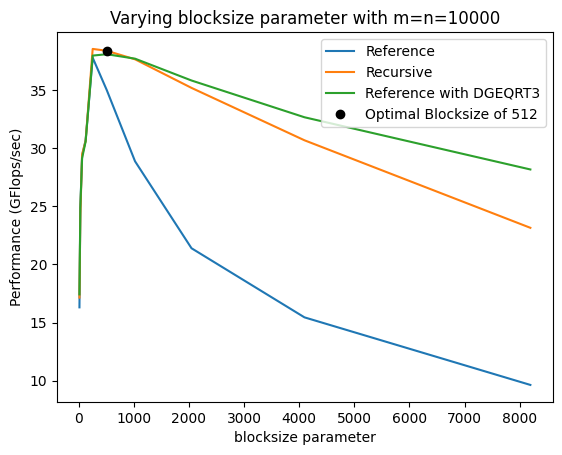

In [11]:
plt.plot(nb[index3Start:],avgRefPerf[index3Start:],label="Reference")
plt.plot(nb[index3Start:],avgRecPerf[index3Start:],label="Recursive")
plt.plot(nb[index3Start:],avgQr3Perf[index3Start:],label="Reference with DGEQRT3")
plt.plot(nb[nb==512],avgRecPerf[nb==512],'ko',label="Optimal Blocksize of 512")
plt.legend()
plt.title("Varying blocksize parameter with m=n=10000")
plt.xlabel("blocksize parameter")
plt.ylabel("Performance (GFlops/sec)")
plt.savefig("newBlocksizePerf.pdf")

In [17]:
def readDlarftFile(fileName):
    """
        This function reads the file given by fileName and returns an array of arrays of the 
        reference, recursive, and optimized values along with the n and k vals for each.
        [avgRefTime, avgRefPerf, avgRecTime, avgRecPerf, avgOptTime, avgOptPerf, n, k]
    """
    avgRefTime = np.zeros(0)
    avgRefPerf = np.zeros(0)
    avgRecTime = np.zeros(0)
    avgRecPerf = np.zeros(0)
    avgOptTime = np.zeros(0)
    avgOptPerf = np.zeros(0)
    nVec = np.zeros(0).astype("int")
    kVec = np.zeros(0).astype("int")
    invalidFileMessage = "Invalid file!\n" + "Please ensure you use the one my shell script outputs"
    
    avgRefTimeTmp = 0
    avgRefPerfTmp = 0
    avgRecTimeTmp = 0
    avgRecPerfTmp = 0
    avgOptTimeTmp = 0
    avgOptPerfTmp = 0
    firstRun = True
    # Open the file and immediately close once done
    with open(fileName, 'r') as file:
        # Read the file line by line
        for line in file:
            # Parse the line.
            # If the line starts with "T" then we skip it. This is for debugging and
            #  visual inspection
            if line[0] == "T":
                if not firstRun:
                    avgRefTime = np.append(avgRefTime, avgRefTimeTmp/10.0)
                    avgRefPerf = np.append(avgRefPerf, avgRefPerfTmp/10.0)
                    avgRecTime = np.append(avgRecTime, avgRecTimeTmp/10.0)
                    avgRecPerf = np.append(avgRecPerf, avgRecPerfTmp/10.0)
                    avgOptTime = np.append(avgOptTime, avgOptTimeTmp/10.0)
                    avgOptPerf = np.append(avgOptPerf, avgOptPerfTmp/10.0)
                avgRefTimeTmp = 0
                avgRefPerfTmp = 0
                avgRecTimeTmp = 0
                avgRecPerfTmp = 0
                avgOptTimeTmp = 0
                avgOptPerfTmp = 0
                firstRun = False
                continue
            # If the line starts with "n" then we parse it. This
            #  is used to print out the parameters used. This is needed for us
            if line[0] == 'n':
                # Determine if we are on a line that contains nb
                tokens = line.split(" ")
                if tokens[-1][0] == "k":
                    # This means we need to update our info (may be update nb or may be update m)
                    try:
                        n = int(tokens[0][2:])
                        k = int(tokens[1][2:])
                    except:
                        print(invalidFileMessage)
                        return None
                    nVec  = np.append(nVec,  n)
                    kVec  = np.append(kVec,  k)
                else:
                    # Then we have a line that's only for visual inspection, so skip it
                    continue
            else:
                # Grab the part of the line that is after our marker
                break1 = line.split(":")
                valPortion = break1[1]
                vals = valPortion.split("|")
                try:
                    timeVal = float(vals[0])
                    perfVal = float(vals[1])
                    #print(timeVal)
                    #print(perfVal)
                except:
                    print(invalidFileMessage)
                    return None
                # Then we need to determine if we have a recursive or reference line 
                typeString = break1[0]
                #print(typeString)
                if typeString == "rec":
                    # This means we have a line that gives us the recursive results. This
                    #  always happens direction after the reference line
                    avgRecTimeTmp += timeVal
                    avgRecPerfTmp += perfVal
                elif typeString == "ref":
                    # This means we have a line that gives us the reference results. This
                    #  is always the 'first' of our pairs
                    avgRefTimeTmp += timeVal
                    avgRefPerfTmp += perfVal
                elif typeString == "opt":
                    avgOptTimeTmp += timeVal
                    avgOptPerfTmp += perfVal
                else:
                    # This file is not properly formatted, inform the user and bail out
                    print(invalidFileMessage)
                    return None
    # Get ready to return our data
    avgRefTime = np.append(avgRefTime, avgRefTimeTmp/10.0)
    avgRefPerf = np.append(avgRefPerf, avgRefPerfTmp/10.0)
    avgRecTime = np.append(avgRecTime, avgRecTimeTmp/10.0)
    avgRecPerf = np.append(avgRecPerf, avgRecPerfTmp/10.0)
    avgOptTime = np.append(avgOptTime, avgOptTimeTmp/10.0)
    avgOptPerf = np.append(avgOptPerf, avgOptPerfTmp/10.0)
    return [avgRefTime, avgRefPerf, avgRecTime, avgRecPerf, avgOptTime, avgOptPerf, nVec, kVec]

In [18]:
[avgRefTime, avgRefPerf, avgRecTime, avgRecPerf, avgOptTime, avgOptPerf, n, k] = readDlarftFile("./larft/realDouble/cTesters/dlarft_timing_smaller.15.November.2024.txt")

In [19]:
print(avgRefTime)

[1.601969e-04 3.406630e-03 1.208740e-02 2.602950e-02 4.854280e-02
 9.175210e-02 1.646920e-01 2.501440e-01 3.479490e-01 4.596360e-01
 5.831640e-01 7.207790e-01 8.640700e-01 1.017790e+00 1.189780e+00
 1.368220e+00 1.567030e+00 1.761820e+00 1.965960e+00 2.195180e+00
 2.409370e+00 2.660940e+00 2.893260e+00 3.132670e+00 3.401320e+00
 3.667630e+00 3.965610e+00 4.250670e+00 4.503510e+00 4.842090e+00
 5.125350e+00 5.449750e+00 5.710120e+00 6.098120e+00 6.460990e+00
 6.754010e+00 7.119920e+00 7.359030e+00 7.772750e+00 8.166050e+00
 8.579130e+00 9.121100e+00 9.241400e+00 9.560410e+00 9.888860e+00
 1.024460e+01 1.087400e+01 1.099170e+01 1.139460e+01 1.174660e+01
 1.198730e+01]


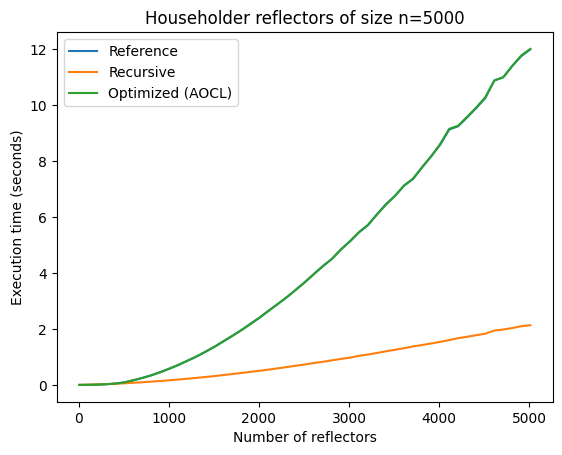

In [20]:
plt.plot(k,avgRefTime,label="Reference")
plt.plot(k,avgRecTime,label="Recursive")
plt.plot(k,avgOptTime,label="Optimized (AOCL)")
plt.legend()
plt.title("Householder reflectors of size n=5000")
plt.xlabel("Number of reflectors")
plt.ylabel("Execution time (seconds)")
plt.savefig("varyBlocksizeDlarftTime.pdf")

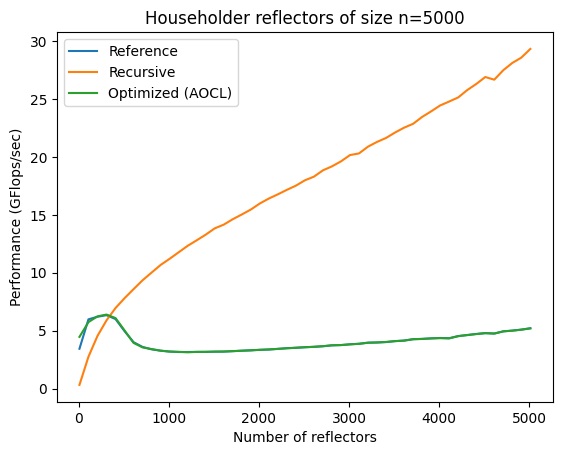

In [21]:
plt.plot(k,avgRefPerf,label="Reference")
plt.plot(k,avgRecPerf,label="Recursive")
plt.plot(k,avgOptPerf,label="Optimized (AOCL)")
plt.legend()
plt.title("Householder reflectors of size n=5000")
plt.xlabel("Number of reflectors")
plt.ylabel("Performance (GFlops/sec)")
plt.savefig("varyBlocksizeDlarftPerf.pdf")

In [22]:
print(avgRefPerf[np.abs(avgRefPerf-avgRecPerf) < 1/2])
print(avgRecPerf[np.abs(avgRefPerf-avgRecPerf) < 1/2])
print(k[np.abs(avgRefPerf-avgRecPerf) < 1/2])

[6.34397]
[5.89324]
[310]


# Note
Crossover happens at a block size of around 310, so we only expect the new method to be 
more performant if we are above this threshold

In [10]:
def readDorgqrLqFile(filename):
    #
    qrNewPerfVec = np.zeros(0)
    qrOldPerfVec = np.zeros(0)
    qrOptPerfVec = np.zeros(0)
    lqNewPerfVec = np.zeros(0)
    lqOldPerfVec = np.zeros(0)
    lqOptPerfVec = np.zeros(0)
    qrNewPerf = 0
    qrOldPerf = 0
    qrOptPerf = 0
    lqNewPerf = 0
    lqOldPerf = 0
    lqOptPerf = 0
    mVec = np.zeros(0).astype('int')
    nVec = np.zeros(0).astype('int')
    firstRun = True
    with open(filename) as file:
        # Read file line by line
        for line in file:
            # A file that was generated from my batch script will have the form
            # m=$m, n=$n [k=$n]
            # Testing file ran 10 times
            # qr:New:perf
            # lq:New:perf
            # qr:Old:perf
            # lq:Old:perf
            # qr:Opt:perf
            # lq:Opt:perf
            # Repeat x9
            # m=$m n=$n [k=$n]
            #...
            if lineStartsWith(line, ["m"]):
                # parse m,n and store them
                vals = line.split(" ")
                m = -1
                n = -1
                try:
                    m = int(vals[0][2:-1])
                    n = int(vals[1][2:])
                except:
                    print("Failed to parse current line as two integers\n")
                    print("Line was: " + line)
                # m and n are the values we will run the next experiments with
                # Add them to our list for later graphing
                mVec = np.append(mVec, m)
                nVec = np.append(nVec, n)
            elif lineStartsWith(line, ["T"]):
                # Skip over this line, maybe add to list depending on structure
                if firstRun:
                    firstRun=False
                    continue
                # At this point we have parsed some values and should append them to the
                # respective lists
                qrNewPerfVec = np.append(qrNewPerfVec, qrNewPerf/10.0)
                qrOldPerfVec = np.append(qrOldPerfVec, qrOldPerf/10.0)
                qrOptPerfVec = np.append(qrOptPerfVec, qrOptPerf/10.0)
                lqNewPerfVec = np.append(lqNewPerfVec, lqNewPerf/10.0)
                lqOldPerfVec = np.append(lqOldPerfVec, lqOldPerf/10.0)
                lqOptPerfVec = np.append(lqOptPerfVec, lqOptPerf/10.0)
                qrNewPerf = 0
                qrOldPerf = 0
                qrOptPerf = 0
                lqNewPerf = 0
                lqOldPerf = 0
                lqOptPerf = 0
            else:
                # break the line over ':'
                tokens = line.split(":")
                try:
                    value = float(tokens[2])
                except:
                    print("Failed to parse current line as type:version:perfVal\n")
                    print("Line was " + line)
                    return None
                if tokens[0] == "qr":
                    if tokens[1] == "New":
                        qrNewPerf += value
                    elif tokens[1] == "Old":
                        qrOldPerf += value
                    elif tokens[1] == "Opt":
                        qrOptPerf += value
                    else:
                        print("Failed to parse current line as type:version:perfVal\n")
                        print("Line was " + line)
                        return None
                elif tokens[0] == "lq":
                    if tokens[1] == "New":
                        lqNewPerf += value
                    elif tokens[1] == "Old":
                        lqOldPerf += value
                    elif tokens[1] == "Opt":
                        lqOptPerf += value
                    else:
                        print("Failed to parse current line as type:version:perfVal\n")
                        print("Line was " + line)
                        return None
                else:
                    print("Failed to parse current line as type:version:perfVal\n")
                    print("Line was " + line)
                    return None
        # At this point we have parsed some values and should append them to the
        # respective lists
        qrNewPerfVec = np.append(qrNewPerfVec, qrNewPerf/10.0)
        qrOldPerfVec = np.append(qrOldPerfVec, qrOldPerf/10.0)
        qrOptPerfVec = np.append(qrOptPerfVec, qrOptPerf/10.0)
        lqNewPerfVec = np.append(lqNewPerfVec, lqNewPerf/10.0)
        lqOldPerfVec = np.append(lqOldPerfVec, lqOldPerf/10.0)
        lqOptPerfVec = np.append(lqOptPerfVec, lqOptPerf/10.0)
    return (qrNewPerfVec, qrOldPerfVec, qrOptPerfVec, lqNewPerfVec, lqOldPerfVec, lqOptPerfVec, mVec, nVec)

In [11]:
(qrNewPerfVec, qrOldPerfVec, qrOptPerfVec, lqNewPerfVec, lqOldPerfVec,\
 lqOptPerfVec, mVec, nVec) = readDorgqrLqFile("./qr/realDouble/timingFiles/dorgqrDorglqTiming.01.March.2025.txt")


In [12]:
print(qrNewPerfVec)
print(nVec)

[30.67453992 29.05503158 29.34097003 28.52225681 27.52711675 30.61864394
 28.45005716 28.79695613]
[ 5000  7000  9000 11000 13000 15000 17000 19000]


/tmp/ipykernel_17685/1701061584.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


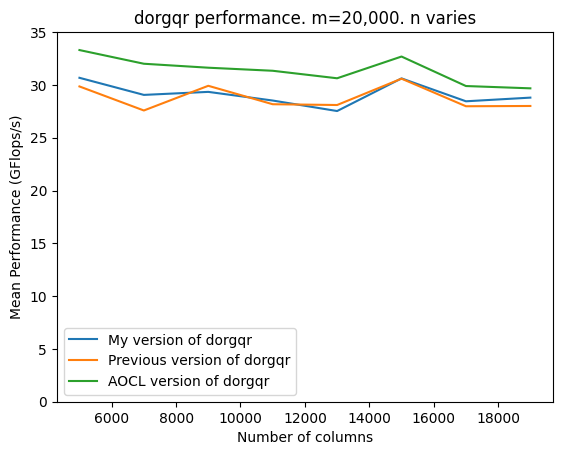

In [19]:
createGraphs(nVec, [qrNewPerfVec, qrOldPerfVec, qrOptPerfVec],\
             ["My version of dorgqr", "Previous version of dorgqr", "AOCL version of dorgqr"],\
             "dorgqr performance. m=20,000. n varies", "Number of columns",\
             "Mean Performance (GFlops/s)", [0, 5, 10, 15, 20, 25, 30, 35], "dorgqrPerfExperiments.pdf")

/tmp/ipykernel_17685/1701061584.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


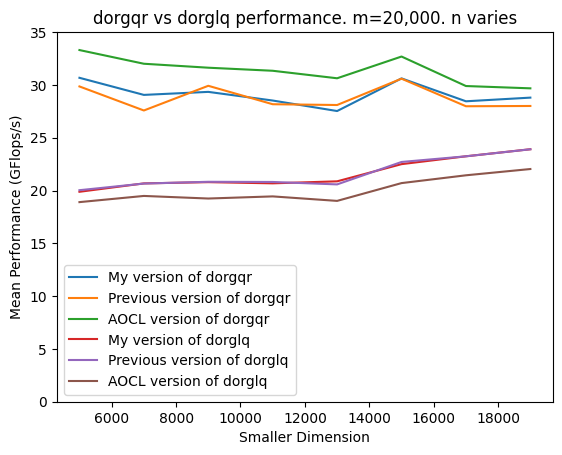

In [20]:
createGraphs(nVec, [qrNewPerfVec, qrOldPerfVec, qrOptPerfVec, lqNewPerfVec, lqOldPerfVec, lqOptPerfVec],\
             ["My version of dorgqr", "Previous version of dorgqr", "AOCL version of dorgqr", \
              "My version of dorglq", "Previous version of dorglq", "AOCL version of dorglq"],\
             "dorgqr vs dorglq performance. m=20,000. n varies", "Smaller Dimension",\
             "Mean Performance (GFlops/s)", [0, 5, 10, 15, 20, 25, 30, 35], "dorgqrDorglqPerfExperiments.pdf")

/tmp/ipykernel_17685/1701061584.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


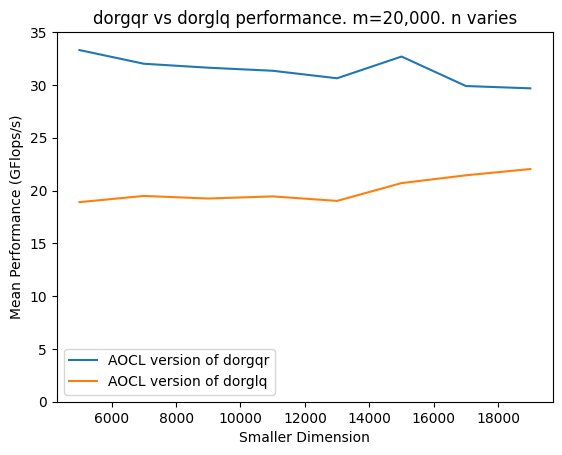

In [21]:
createGraphs(nVec, [qrOptPerfVec, lqOptPerfVec],\
             ["AOCL version of dorgqr", "AOCL version of dorglq"],\
             "dorgqr vs dorglq performance. m=20,000. n varies", "Smaller Dimension",\
             "Mean Performance (GFlops/s)", [0, 5, 10, 15, 20, 25, 30, 35], "dorgqrDorglqOptPerfExperiments.pdf")